# MultiLayer Perceptron - Training

## Problem Statement

To classify grayscale images of handwritten digits (28 × 28 pixels) into 10 categories (0 through 9). We’ll use the *MNIST* dataset. It’s a set of 60,000 training images, plus 10,000 test images, assembled by the National Institute of Standards and Technology (the NIST in MNIST)

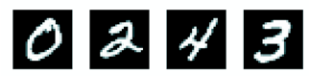

In [33]:
import tensorflow
from tensorflow import keras

In [34]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

In [35]:
train_images.shape

(60000, 28, 28)

In [36]:
test_images.shape

(10000, 28, 28)

In [37]:
import matplotlib.pyplot as plt

In [38]:
train_images[0].shape

(28, 28)

Label:  5


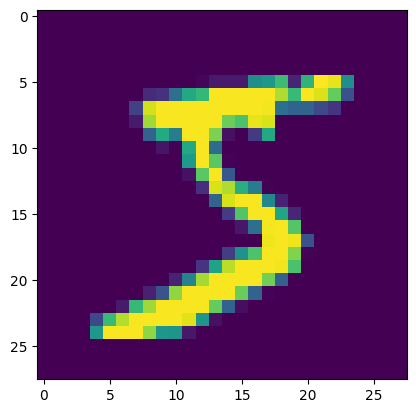

In [39]:
print("Label: ", train_labels[0])
plt.imshow(train_images[0])
plt.show()

In [41]:
from tensorflow.keras import models, layers

In [43]:
model = models.Sequential()
model.add(layers.Flatten(input_shape=(28,28)))  # Flatten 2D image
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [48]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

To make the network ready for training, we need to pick three more things, as part of the compilation step:
1.  A loss function—How the network will be able to measure its performance on the training data, and thus how it will be able to steer itself in the right direction.
2.  An optimizer—The mechanism through which the network will update itself
based on the data it sees and its loss function.
3.  Metrics to monitor during training and testing—Here, we’ll only care about accuracy (the fraction of the images that were correctly classified).

In [49]:
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Before training, we’ll preprocess the data by reshaping it into the shape the network expects and scaling it so that all values are in the [0, 1] interval.  
Previously, our training images, for instance, were stored in an array of shape (60000, 28, 28) of type uint8 with values in the [0, 255] interval.   
We transform it into a float32 array of shape (60000, 28 * 28) with values between 0 and 1

In [50]:
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

In [25]:
train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

In [52]:
# Training model
history = model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8534 - loss: 0.5414
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8689 - loss: 0.4830
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8739 - loss: 0.4544
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8815 - loss: 0.4270
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8886 - loss: 0.3984


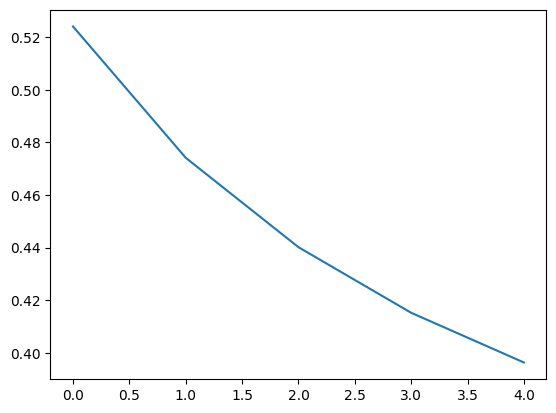

In [59]:
plt.plot(history.history['loss'])


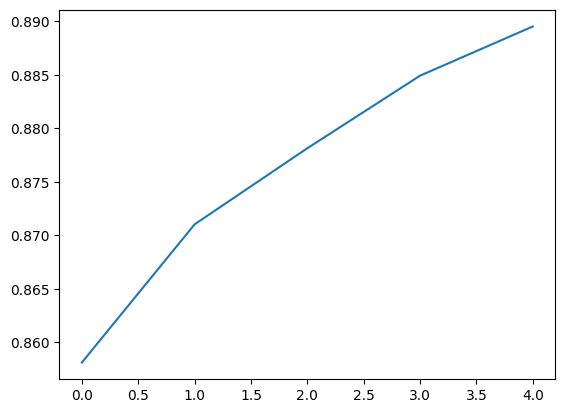

In [60]:
plt.plot(history.history['accuracy'])

In [53]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('test_acc:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8800 - loss: 0.4233
test_acc: 0.8953999876976013


In [54]:
y_prob = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [55]:
y_prob

array([[1.5378679e-04, 5.7235110e-07, 3.7533846e-05, ..., 9.9475718e-01,
        1.0393085e-05, 4.4887699e-03],
       [1.5726218e-02, 1.0802825e-04, 7.4436110e-01, ..., 1.0642892e-08,
        6.5079327e-03, 1.7507470e-07],
       [1.2701062e-05, 9.6423328e-01, 1.3272926e-02, ..., 4.7227405e-03,
        3.2053911e-03, 1.1607053e-03],
       ...,
       [3.8301591e-06, 1.1753630e-05, 7.8287208e-05, ..., 1.0846762e-03,
        1.6433926e-02, 1.9393203e-01],
       [8.2780765e-03, 3.3665916e-03, 6.2374738e-03, ..., 5.7624129e-04,
        2.0343295e-01, 5.3930334e-03],
       [3.9009179e-04, 1.5990720e-10, 9.1821334e-04, ..., 1.0224420e-10,
        5.7323714e-06, 7.1956002e-08]], dtype=float32)

In [56]:
y_pred = y_prob.argmax(axis=1)
y_pred

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [57]:
test_labels

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [58]:
test_images.shape

(10000, 28, 28)

In [63]:
y_pred = model.predict(test_images[0].reshape(1, 28, 28))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


array([[1.5378679e-04, 5.7235167e-07, 3.7533810e-05, 4.5261442e-04,
        1.1738637e-05, 8.7269138e-05, 9.0104685e-08, 9.9475718e-01,
        1.0393095e-05, 4.4887741e-03]], dtype=float32)

In [64]:
y_pred.argmax(axis=1)

array([7], dtype=int64)